<a href="https://colab.research.google.com/github/TummalaSharmila/MachineLearning_in_BI/blob/Assignment-3/ML_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd

# Data points
points = np.array([[1, 2], [2, 2], [4, 4], [5, 4], [5, 5]])

# Initial centroids
centroids = np.array([[1, 2], [2, 2]])

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=1)

def compute_new_centroid(cluster):
    if len(cluster) == 0:
        return np.array([0, 0])
    median_x = np.median([point[0] for point in cluster])
    median_y = np.median([point[1] for point in cluster])
    return np.array([median_x, median_y])

max_iter = 10
for iteration in range(max_iter):
    print(f"\n--- Iteration {iteration + 1} ---")
    clusters = {0: [], 1: []}

    # Step 1: Assign points to closest centroid
    for point in points:
        dists = manhattan_distance(np.array([point]), centroids)
        cluster_id = np.argmin(dists)
        clusters[cluster_id].append(point)

    # Print assignments
    for cid in clusters:
        print(f"Cluster {cid + 1}: {clusters[cid]}")

    # Step 2: Recompute centroids
    new_centroids = []
    for cid in clusters:
        new_c = compute_new_centroid(clusters[cid])
        new_centroids.append(new_c)

    new_centroids = np.array(new_centroids)
    print(f"New centroids: {new_centroids}")

    # Check for convergence
    if np.allclose(centroids, new_centroids):
        print("\nConverged.")
        break
    centroids = new_centroids



--- Iteration 1 ---
Cluster 1: [array([1, 2])]
Cluster 2: [array([2, 2]), array([4, 4]), array([5, 4]), array([5, 5])]
New centroids: [[1.  2. ]
 [4.5 4. ]]

--- Iteration 2 ---
Cluster 1: [array([1, 2]), array([2, 2])]
Cluster 2: [array([4, 4]), array([5, 4]), array([5, 5])]
New centroids: [[1.5 2. ]
 [5.  4. ]]

--- Iteration 3 ---
Cluster 1: [array([1, 2]), array([2, 2])]
Cluster 2: [array([4, 4]), array([5, 4]), array([5, 5])]
New centroids: [[1.5 2. ]
 [5.  4. ]]

Converged.


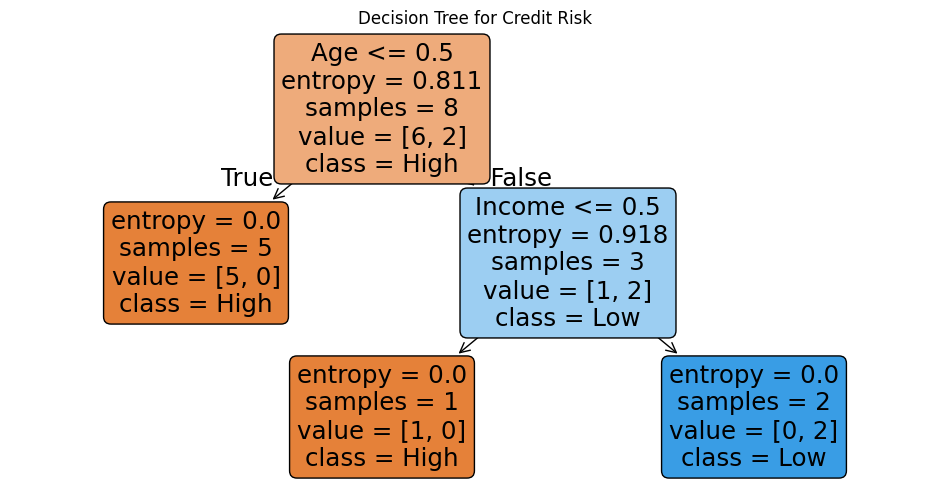

In [6]:
#Q2
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Step 1: Prepare the dataset
data = pd.DataFrame({
    'Age':    ['<25', '<25', '≥25', '≥25', '≥25', '<25', '<25', '<25'],
    'Income': ['>50K', '>50K', '<50K', '>50K', '>50K', '<50K', '<50K', '<50K'],
    'Gender': ['M', 'F', 'F', 'F', 'M', 'M', 'M', 'F'],
    'Risk':   ['High', 'High', 'High', 'Low', 'Low', 'High', 'High', 'High']
})

# Step 2: Encode categorical features
X = data[['Age', 'Income', 'Gender']].apply(LabelEncoder().fit_transform)
y = LabelEncoder().fit_transform(data['Risk'])  # High=0, Low=1 (or vice versa)

# Step 3: Train the decision tree classifier
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

# Step 4: Plot the tree
plt.figure(figsize=(12, 6))
plot_tree(clf,
          feature_names=['Age', 'Income', 'Gender'],
          class_names=['High', 'Low'],
          filled=True,
          rounded=True)
plt.title('Decision Tree for Credit Risk')
plt.show()


In [11]:
#Q3
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# Step 1: Load the Excel file
file_path = 'Immunotherapy.xlsx'

train_df = pd.read_excel(file_path, sheet_name='Training data set')
test_df = pd.read_excel(file_path, sheet_name='Test data set')

# Step 2: Separate features and target
X_train = train_df.drop(columns=['Result_of_Treatment'])
y_train = train_df['Result_of_Treatment']

X_test = test_df.drop(columns=['Result_of_Treatment'])


# Step 3: Training the decision tree model
clf = DecisionTreeClassifier(criterion='entropy')  # ID3-style
clf.fit(X_train, y_train)

# Step 4: Predict on test data
predictions = clf.predict(X_test)

# Step 5: Output predictions
print("Predictions on Test Data:")
print(predictions)


Predictions on Test Data:
[-1 -1  1  1  1  1  1 -1 -1  1]


In [2]:
import pandas as pd
from sklearn.svm import SVC

# Step 1: Load the data from Excel
train_df = pd.read_excel("Immunotherapy.xlsx", sheet_name="Training data set")
test_df = pd.read_excel("Immunotherapy.xlsx", sheet_name="Test data set")

# Step 2: Split into features and target
X_train = train_df.drop(columns=['Result_of_Treatment'])  # Replace 'Result' if your target column is named differently
y_train = train_df['Result_of_Treatment']

X_test = test_df.drop(columns=['Result_of_Treatment'])  # Only if 'Result' exists in test set
# If the test set doesn't include 'Result', just use X_test = test_df

# Step 3: Train SVM classifier with linear kernel
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

# Step 4: Make predictions on the test set
predictions = svm_clf.predict(X_test)

# Step 5: Display the results
print("SVM Predictions on Test Data:")
print(predictions)


SVM Predictions on Test Data:
[1 1 1 1 1 1 1 1 1 1]
